# The Blockbuster Formula
### Bayesian Network Analysis of Box Office Success (2000-2025)

This notebook investigates a simple but commercially important question: **what actually drives a film toward blockbuster status rather than flop territory?** Instead of treating box office success as a purely descriptive problem, the project models it as a probabilistic system of connected pre-release decisions.

The analysis combines **TMDb film metadata**, **The Numbers budget/revenue supplementation**, and a **hybrid Bayesian Network** to estimate how four major factors interact:

- **Budget tier**
- **Genre**
- **Actor prestige**
- **Release window**

Rather than asking only which variables correlate with revenue, the notebook asks a more useful strategic question: **if a studio locks in a certain budget, genre, cast profile, and release timing, how does the probability of Blockbuster, Hit, Break-even, or Flop change?**

The workflow covers the full pipeline end to end:

1. **Collect and clean film-level data** for releases between 2000 and 2025.
2. **Adjust financial values for inflation** so cross-era comparisons are meaningful.
3. **Engineer a commercially grounded outcome label** using a hybrid revenue + ROI definition.
4. **Estimate actor prestige** from a weighted ensemble of the top-billed cast.
5. **Train and interpret a Bayesian Network** using both structure learning and domain knowledge.
6. **Compare the BN against baseline ML models** and visualize the main business takeaways.

The final output is not just a model, but a decision framework: a way to reason about how different creative and financial choices shift the odds of success in different market eras.

---


## Section 0 - Setup & Imports

In [3]:
import os
import re
import time
import warnings
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from pathlib import Path
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup

# pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, PC, BIC
from pgmpy.inference import VariableElimination
import pgmpy

# sklearn
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    multilabel_confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Paths
DATA_PATH    = Path('data')
OUTPUTS_PATH = Path('outputs')
DATA_PATH.mkdir(exist_ok=True)
OUTPUTS_PATH.mkdir(exist_ok=True)

# Colour palette used across all plots
OUTCOME_COLORS = {
    'Flop':        '#e74c3c',
    'Break-even':  '#f39c12',
    'Hit':         '#2ecc71',
    'Blockbuster': '#2980b9',
}
outcome_order = ['Flop', 'Break-even', 'Hit', 'Blockbuster']

# API
load_dotenv()
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
if not TMDB_API_KEY:
    raise ValueError('TMDb API key not found. Add TMDB_API_KEY to your .env file.')

print(f'pgmpy {pgmpy.__version__} | pandas {pd.__version__} | numpy {np.__version__}')
print('All imports OK.')

C:\Users\steve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


pgmpy 1.1.0 | pandas 2.2.3 | numpy 2.2.3
All imports OK.


## Section 1 - Data Collection

In [4]:
# TMDb API config and helper
TMDB_BASE    = 'https://api.themoviedb.org/3'
TMDB_HEADERS = {'accept': 'application/json'}
START_YEAR   = 2000
END_YEAR     = 2025
PAGES_PER_YEAR = 10
REQUEST_DELAY  = 0.25

RAW_PATH  = DATA_PATH / 'movies_raw_v2.csv'
SUPP_PATH = DATA_PATH / 'numbers_supplement_v2.csv'
FEAT_PATH = DATA_PATH / 'movies_featured_v2.csv'

def tmdb_get(endpoint, params=None):
    url = f'{TMDB_BASE}/{endpoint}'
    all_params = {'api_key': TMDB_API_KEY}
    if params:
        all_params.update(params)
    try:
        r = requests.get(url, headers=TMDB_HEADERS, params=all_params, timeout=10)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.RequestException as e:
        print(f'Request failed for {endpoint}: {e}')
        return None

test = tmdb_get('configuration')
print('TMDb connection:', 'OK' if test else 'FAILED -- check API key')


TMDb connection: OK


In [6]:
# Smart loader -- skip API calls if raw data already exists
if RAW_PATH.exists():
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Raw data already exists -- loaded {len(df_raw)} rows from {RAW_PATH}')
    print(f'Date range: {df_raw["release_date"].min().year} - {df_raw["release_date"].max().year}')
    print('Skip to the Numbers supplement cell below.')
else:
    print(f'{RAW_PATH} not found -- run the cells below to fetch from TMDb.')
    df_raw = None


Raw data already exists -- loaded 4741 rows from data\movies_raw_v2.csv
Date range: 2000 - 2025
Skip to the Numbers supplement cell below.


In [14]:
# Step 1: Discover movie IDs per year -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def discover_ids(year, pages=PAGES_PER_YEAR):
        ids = []
        for page in range(1, pages + 1):
            data = tmdb_get('discover/movie', params={
                'primary_release_year': year, 'sort_by': 'popularity.desc',
                'include_adult': False, 'include_video': False,
                'page': page, 'language': 'en-US', 'with_original_language': 'en',
            })
            if data and 'results' in data:
                ids.extend([m['id'] for m in data['results']])
            time.sleep(REQUEST_DELAY)
        return ids

    print(f'Discovering IDs {START_YEAR} - {END_YEAR}...')
    all_ids = []
    for year in tqdm(range(START_YEAR, END_YEAR + 1), desc='Years'):
        all_ids.extend(discover_ids(year))
    all_ids = list(set(all_ids))
    print(f'Unique IDs collected: {len(all_ids)}')


Discovering IDs 2000 - 2025...


Years:   0%|          | 0/26 [00:00<?, ?it/s]

Unique IDs collected: 4741


In [15]:
# Step 2: Fetch details + credits -- skip if raw data already loaded
if df_raw is not None:
    print('Raw data already loaded -- skipping.')
else:
    def fetch_details(movie_id):
        details = tmdb_get(f'movie/{movie_id}', params={'language': 'en-US'})
        if not details:
            return None
        credits = tmdb_get(f'movie/{movie_id}/credits', params={'language': 'en-US'})
        cast_list, cast_ids = [], []
        if credits and 'cast' in credits:
            top = sorted(credits['cast'], key=lambda x: x.get('order', 99))[:5]
            cast_list = [c['name'] for c in top]
            cast_ids  = [str(c['id']) for c in top]
        return {
            'tmdb_id': movie_id,
            'title': details.get('title', ''),
            'release_date': details.get('release_date', ''),
            'genres': '|'.join(g['name'] for g in details.get('genres', [])),
            'budget': details.get('budget', 0),
            'revenue': details.get('revenue', 0),
            'runtime': details.get('runtime', 0),
            'popularity': details.get('popularity', 0),
            'vote_average': details.get('vote_average', 0),
            'vote_count': details.get('vote_count', 0),
            'original_language': details.get('original_language', ''),
            'cast_names': '|'.join(cast_list),
            'cast_ids':   '|'.join(cast_ids),
        }

    print(f'Fetching details for {len(all_ids)} movies...')
    movies, failed = [], []
    for mid in tqdm(all_ids, desc='Movies'):
        rec = fetch_details(mid)
        if rec: movies.append(rec)
        else:   failed.append(mid)
        time.sleep(REQUEST_DELAY)   
    print(f'Fetched: {len(movies)}  |  Failed: {len(failed)}')


Fetching details for 4741 movies...


Movies:   0%|          | 0/4741 [00:00<?, ?it/s]

Fetched: 4741  |  Failed: 0


In [7]:
# Step 3: Build DataFrame and save
if df_raw is not None:
    print('Raw data already loaded -- skipping build.')
else:
    df_raw = pd.DataFrame(movies)
    df_raw['release_date'] = pd.to_datetime(df_raw['release_date'], errors='coerce')
    df_raw['release_year'] = df_raw['release_date'].dt.year
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw)} rows to {RAW_PATH}')

print(f'Shape: {df_raw.shape}')
df_raw.head(3)


Raw data already loaded -- skipping build.
Shape: (4741, 14)


,tmdb_id,title,release_date,genres,budget,revenue,runtime,popularity,vote_average,vote_count,original_language,cast_names,cast_ids,release_year
0,8193,Napoleon Dynamite,2004-06-11,Comedy,400000,46118097,95,3.4054,6.783,2127,en,Jon Heder|Efren Ramirez|Tina Majorino|Aaron Ru...,53926|20190|53930|53927|9629,2004
1,8198,The Quiet American,2002-11-22,Romance|Thriller|Drama|War,30000000,27674124,101,1.5456,6.545,325,en,Michael Caine|Brendan Fraser|Đỗ Thị Hải Yến|Tz...,3895|18269|53962|21629|1118,2002
2,614409,To All the Boys: Always and Forever,2021-02-12,Romance|Comedy|Drama,0,0,114,2.8253,7.502,2054,en,Lana Condor|Noah Centineo|Janel Parrish|Anna C...,1452046|1253353|93377|1683266|1299232,2021


In [8]:
# Raw data overview
print('=== Raw Data Summary ===')
print(f'Total rows:         {len(df_raw)}')
print(f'Budget  > 0:        {(df_raw["budget"] > 0).sum()}')
print(f'Revenue > 0:        {(df_raw["revenue"] > 0).sum()}')
print(f'Both zero:          {((df_raw["budget"]==0) & (df_raw["revenue"]==0)).sum()}')
print(f'Date range:         {df_raw["release_date"].min().date()} to {df_raw["release_date"].max().date()}')
bnz = df_raw[df_raw['budget']  > 0]['budget']
rnz = df_raw[df_raw['revenue'] > 0]['revenue']
print(f'Budget  min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')


=== Raw Data Summary ===
Total rows:         4741
Budget  > 0:        3551
Revenue > 0:        3599
Both zero:          869
Date range:         2000-01-01 to 2025-12-28
Budget  min/med/max: $5 / $30,000,000 / $489,900,000
Revenue min/med/max: $7 / $54,700,000 / $2,923,706,026


In [ ]:
# The Numbers budget supplement
# Fills in missing production budgets for films TMDb has at $0 but revenue > $5M.
# Cached to SUPP_PATH. Set FORCE_REFETCH=True to re-scrape.

FORCE_REFETCH = False
TN_BASE    = 'https://www.the-numbers.com/movie/'
TN_HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def _tn_slug(title, year=None):
    t = title.strip()
    for art in ['The ', 'A ', 'An ']:
        if t.startswith(art):
            t = t[len(art):] + '-' + art.strip()
            break
    t = re.sub(r"[\u2019\u2018']", '', t)
    t = re.sub(r'[^a-zA-Z0-9-]', '-', t)
    t = re.sub(r'-+', '-', t).strip('-')
    return f'{t}-({year})' if year else t

def _tn_parse(html):
    text = html.replace('\xa0', ' ')
    soup = BeautifulSoup(text, 'html.parser')
    budget = revenue = None
    m = re.search(r'Production Budget:\s*\$([\d,]+)', text)
    if m:
        budget = int(m.group(1).replace(',', ''))
    for row in soup.find_all('tr'):
        if 'Worldwide Box Office' in row.get_text():
            m2 = re.search(r'\$([\d,]+)', row.get_text())
            if m2:
                revenue = int(m2.group(1).replace(',', ''))
                break
    return budget, revenue

def _tn_fetch(title, year):
    slugs = list(dict.fromkeys([
        _tn_slug(title), _tn_slug(title, year),
        _tn_slug(title.replace('&', 'and')), _tn_slug(title.replace('&', 'and'), year),
    ]))
    for slug in slugs:
        try:
            r = requests.get(TN_BASE + slug, headers=TN_HEADERS, timeout=8)
            if r.status_code == 200:
                b, rev = _tn_parse(r.text)
                if b or rev:
                    return b, rev
        except Exception:
            pass
        time.sleep(0.25)
    return None, None

if SUPP_PATH.exists() and not FORCE_REFETCH:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Cached supplement loaded: {SUPP_PATH}')
else:
    _tmp = df_raw.copy()
    _tmp['budget']  = pd.to_numeric(_tmp['budget'],  errors='coerce').fillna(0)
    _tmp['revenue'] = pd.to_numeric(_tmp['revenue'], errors='coerce').fillna(0)
    _tmp['release_year'] = pd.to_datetime(_tmp['release_date'], errors='coerce').dt.year
    targets = _tmp[(_tmp['budget'] == 0) & (_tmp['revenue'] > 5_000_000)]
    print(f'Fetching {len(targets)} films from The Numbers...')
    rows = []
    for _, row in tqdm(targets.iterrows(), total=len(targets)):
        yr = int(row['release_year']) if pd.notna(row['release_year']) else None
        b, rev = _tn_fetch(row['title'], yr)
        rows.append({'tmdb_id': row['tmdb_id'], 'title': row['title'],
                     'numbers_budget': b, 'numbers_revenue': rev})
        time.sleep(0.4)
    df_supp = pd.DataFrame(rows)
    df_supp.to_csv(SUPP_PATH, index=False)
    print(f'Saved to {SUPP_PATH}')

matched = df_supp[df_supp['numbers_budget'].notna()]
print(f'Budgets recovered: {len(matched)} / {len(df_supp)}')
top = matched[['title','numbers_budget']].sort_values('numbers_budget', ascending=False).head(10)
print(top.to_string(index=False))

## Section 2 - Data Cleaning

In [9]:
# Load raw data and merge The Numbers supplement to fill missing budgets
if 'df_raw' not in dir() or df_raw is None:
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Loaded {len(df_raw)} rows from {RAW_PATH}')

df = df_raw.copy()
df['budget']      = pd.to_numeric(df['budget'],  errors='coerce').fillna(0)
df['revenue']     = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Merge supplement
if 'df_supp' not in dir() or df_supp is None:
    df_supp = pd.read_csv(SUPP_PATH)
    print(f'Loaded supplement: {len(df_supp)} rows')

df = df.merge(df_supp[['tmdb_id', 'numbers_budget', 'numbers_revenue']], on='tmdb_id', how='left')

# Patch zeros with The Numbers values where available
mask_b = (df['budget']  == 0) & df['numbers_budget'].notna()
mask_r = (df['revenue'] == 0) & df['numbers_revenue'].notna()
df.loc[mask_b, 'budget']  = df.loc[mask_b, 'numbers_budget']
df.loc[mask_r, 'revenue'] = df.loc[mask_r, 'numbers_revenue']
df.drop(columns=['numbers_budget', 'numbers_revenue'], inplace=True)

print(f'Budget  > 0: {(df["budget"]  > 0).sum()}  (was {(df_raw["budget"]  > 0).sum()})')
print(f'Revenue > 0: {(df["revenue"] > 0).sum()}  (was {(df_raw["revenue"] > 0).sum()})')

Loaded supplement: 105 rows
Budget  > 0: 3551  (was 3551)
Revenue > 0: 3599  (was 3599)


In [10]:
# Inflate all financials to 2024 dollars using US CPI-U annual averages
CPI_BASE = 314.796  # 2024 annual average

CPI_TABLE = {
    2000: 172.2,   2001: 177.1,   2002: 179.9,   2003: 184.0,   2004: 188.9,
    2005: 195.3,   2006: 201.6,   2007: 207.3,   2008: 215.3,   2009: 214.5,
    2010: 218.1,   2011: 224.9,   2012: 229.6,   2013: 233.0,   2014: 236.7,
    2015: 237.0,   2016: 240.0,   2017: 245.1,   2018: 251.1,   2019: 255.7,
    2020: 258.8,   2021: 270.970, 2022: 292.655, 2023: 304.702,
    2024: 314.796, 2025: 319.1,
}

df['cpi']         = df['release_year'].map(CPI_TABLE).fillna(CPI_BASE)
df['budget_adj']  = (df['budget']  * CPI_BASE / df['cpi']).round(0)
df['revenue_adj'] = (df['revenue'] * CPI_BASE / df['cpi']).round(0)

mult_2000 = CPI_BASE / CPI_TABLE[2000]
print(f'Inflation base: 2024 (CPI = {CPI_BASE})')
print(f'2000→2024 multiplier: {mult_2000:.3f}x  (e.g. $100M → ${100_000_000 * mult_2000:,.0f})')

Inflation base: 2024 (CPI = 314.796)
2000→2024 multiplier: 1.828x  (e.g. $100M → $182,808,362)


In [11]:
# Filter to films with known financials; remove data-entry errors only
# No minimum budget floor -- inflation adjustment handles era differences
n_before = len(df)

df_clean = df[
    (df['budget_adj'] > 0) &
    (df['revenue_adj'] > 0) &
    (df['budget_adj']  < 700_000_000) &   # no film has ever cost >$700M adj.
    (df['revenue_adj'] < 6_000_000_000)   # highest ever ~$2.9B adj.
    ].copy()

print(f'Rows before filter: {n_before}')
print(f'Rows after  filter: {len(df_clean)}  ({n_before - len(df_clean)} removed)')
print(f'Year range: {df_clean["release_year"].min():.0f} – {df_clean["release_year"].max():.0f}')

Rows before filter: 4741
Rows after  filter: 3278  (1463 removed)
Year range: 2000 – 2025


In [12]:
# Cleaned data overview
print('=== Cleaned Dataset ===')
print(f'Total films:  {len(df_clean)}')
bnz = df_clean['budget_adj']
rnz = df_clean['revenue_adj']
print(f'Budget  (adj) min/med/max: ${bnz.min():,.0f} / ${bnz.median():,.0f} / ${bnz.max():,.0f}')
print(f'Revenue (adj) min/med/max: ${rnz.min():,.0f} / ${rnz.median():,.0f} / ${rnz.max():,.0f}')
print(f'\nFilms per year:')
print(df_clean.groupby('release_year').size().rename('count').to_string())

=== Cleaned Dataset ===
Total films:  3278
Budget  (adj) min/med/max: $7 / $45,132,043 / $603,123,036
Revenue (adj) min/med/max: $7 / $93,596,301 / $4,290,773,716

Films per year:
release_year
2000    130
2001    144
2002    145
2003    143
2004    148
2005    152
2006    144
2007    151
2008    140
2009    136
2010    141
2011    142
2012    135
2013    140
2014    142
2015    123
2016    131
2017    123
2018    124
2019    118
2020     64
2021     78
2022     77
2023     93
2024    110
2025    104


## Section 3 - Feature Engineering

In [13]:
# Outcome label: Flop / Break-even / Hit / Blockbuster
# Hybrid labeling: absolute revenue scale + profit ratio efficiency
#
# Rules (evaluated in priority order):
#   Blockbuster : revenue >= $400M                          (cultural event, scale alone)
#   Hit         : revenue >= $150M AND ratio >= 1.5x        (strong mainstream performer)
#              OR  revenue >= $30M  AND ratio >= 3.0x        (small-scale but exceptional ROI)
#   Flop        : ratio < 1.0                                 (lost money at the box office)
#   Break-even  : everything else                             (covered costs, nothing more)
#
# This fixes the pure-absolute problem (a $50M gross on a $2M budget is NOT a Flop)
# while avoiding the pure-ratio problem (Paranormal Activity on $15K != Blockbuster)

df_clean['profit_ratio'] = df_clean['revenue_adj'] / df_clean['budget_adj']

def assign_outcome_hybrid(row):
    rev   = row['revenue_adj']
    ratio = row['profit_ratio']
    if rev   >= 400e6:                    return 'Blockbuster'
    if rev   >= 150e6 and ratio >= 1.5:   return 'Hit'
    if rev   >= 30e6  and ratio >= 3.0:   return 'Hit'
    if ratio <  1.0:                      return 'Flop'
    return 'Break-even'

df_clean['outcome_label'] = df_clean.apply(assign_outcome_hybrid, axis=1)

print('Outcome labeling: hybrid (revenue scale + profit ratio)')
print('  Blockbuster : revenue >= $400M')
print('  Hit         : (revenue >= $150M AND ratio >= 1.5x) OR (revenue >= $30M AND ratio >= 3.0x)')
print('  Flop        : ratio < 1.0')
print('  Break-even  : everything else')
print()
for label in outcome_order:
    count = (df_clean['outcome_label'] == label).sum()
    pct   = count / len(df_clean) * 100
    print(f'  {label:<12} {count:>4}  ({pct:.1f}%)')

# Sanity check -- the $50M gross / $2M budget case
print()
print('Sanity check: $50M gross on $2M budget ->', assign_outcome_hybrid({'revenue_adj': 50e6, 'profit_ratio': 25.0}))
print('Sanity check: $5M gross on $10M budget  ->', assign_outcome_hybrid({'revenue_adj': 5e6,  'profit_ratio': 0.5}))
print('Sanity check: $500M gross on $200M budget->', assign_outcome_hybrid({'revenue_adj': 500e6,'profit_ratio': 2.5}))

Outcome labeling: hybrid (revenue scale + profit ratio)
  Blockbuster : revenue >= $400M
  Hit         : (revenue >= $150M AND ratio >= 1.5x) OR (revenue >= $30M AND ratio >= 3.0x)
  Flop        : ratio < 1.0
  Break-even  : everything else

  Flop          862  (26.3%)
  Break-even    946  (28.9%)
  Hit           999  (30.5%)
  Blockbuster   471  (14.4%)

Sanity check: $50M gross on $2M budget -> Hit
Sanity check: $5M gross on $10M budget  -> Flop
Sanity check: $500M gross on $200M budget-> Blockbuster


In [14]:
# Budget tiers (2024-adjusted dollars)
BUDGET_BINS   = [0, 10e6, 40e6, 100e6, 200e6, np.inf]
BUDGET_LABELS = ['Micro', 'Low', 'Mid', 'High', 'Mega']

df_clean['budget_tier'] = pd.cut(
    df_clean['budget_adj'],
    bins=BUDGET_BINS, labels=BUDGET_LABELS, right=False
)

print('Budget tier distribution:')
for tier, count in df_clean['budget_tier'].value_counts()[BUDGET_LABELS].items():
    pct = count / len(df_clean) * 100
    print(f'  {tier:<8} {count:>4}  ({pct:.1f}%)')

Budget tier distribution:
  Micro     381  (11.6%)
  Low      1110  (33.9%)
  Mid       998  (30.4%)
  High      533  (16.3%)
  Mega      256  (7.8%)


In [15]:
# Map TMDb genres → 5 BN-friendly categories using the first listed genre
GENRE_MAP = {
    'Action':           'Action',  'Adventure':  'Action',  'Thriller':  'Action',
    'War':              'Action',  'Western':    'Action',
    'Comedy':           'Comedy',  'Animation':  'Comedy',  'Family':    'Comedy',
    'Music':            'Comedy',
    'Drama':            'Drama',   'History':    'Drama',   'Romance':   'Drama',
    'Horror':           'Horror',  'Mystery':    'Horror',  'Crime':     'Horror',
    'Science Fiction':  'Sci-Fi',  'Fantasy':    'Sci-Fi',
}

def primary_genre(genres_str):
    if pd.isna(genres_str) or genres_str == '':
        return 'Other'
    first = genres_str.split('|')[0].strip()
    return GENRE_MAP.get(first, 'Other')

df_clean['genre_bn'] = df_clean['genres'].apply(primary_genre)

print('Genre BN distribution:')
print(df_clean['genre_bn'].value_counts().to_string())

Genre BN distribution:
genre_bn
Action    965
Comedy    845
Drama     772
Horror    485
Sci-Fi    203
Other       8


In [16]:
# Release window (season) from release month
def release_window(month):
    if pd.isna(month): return 'Other'
    m = int(month)
    if m in (6, 7, 8):   return 'Summer'
    if m in (11, 12):    return 'Holiday'
    if m in (3, 4, 5):   return 'Spring'
    return 'Other'   # Jan, Feb, Sep, Oct

df_clean['release_window'] = df_clean['release_date'].dt.month.apply(release_window)

print('Release window distribution:')
print(df_clean['release_window'].value_counts().to_string())

Release window distribution:
release_window
Other      1128
Summer      775
Spring      743
Holiday     632


In [17]:
import json

# Actor prestige via weighted ensemble score across top 3 billed actors
# Billing-order weights: lead × 1.0 | 2nd billed × 0.7 | 3rd billed × 0.5
# Fixes single-lead bias: Avengers-style ensembles now score higher than solo vehicles

ACTOR_CACHE_PATH  = DATA_PATH / 'actor_popularity_cache.json'
FORCE_ACTOR_FETCH = False

def _nth(pipe_str, n):
    if pd.isna(pipe_str) or pipe_str == '': return None
    parts = pipe_str.split('|')
    return parts[n].strip() if len(parts) > n else None

# Extract top 3 actor names and TMDb person IDs
for i, col in enumerate(['lead_actor', 'actor2', 'actor3']):
    df_clean[col] = df_clean['cast_names'].apply(lambda x, n=i: _nth(x, n) or 'Unknown')
for i, col in enumerate(['lead_actor_id', 'actor2_id', 'actor3_id']):
    df_clean[col] = df_clean['cast_ids'].apply(lambda x, n=i: _nth(x, n))

# Build unified actor → TMDb person ID map across all 3 positions
actor_id_map = {}
for name_col, id_col in [('lead_actor','lead_actor_id'),('actor2','actor2_id'),('actor3','actor3_id')]:
    for _, row in df_clean[df_clean[id_col].notna()].drop_duplicates(name_col)[[name_col,id_col]].iterrows():
        if row[name_col] not in actor_id_map:
            actor_id_map[row[name_col]] = row[id_col]

print(f'Unique actors across top-3 billing positions: {len(actor_id_map)}')

# Load cache; only fetch actors not yet cached (regardless of FORCE_ACTOR_FETCH)
if ACTOR_CACHE_PATH.exists() and not FORCE_ACTOR_FETCH:
    with open(ACTOR_CACHE_PATH) as f:
        pop_cache = json.load(f)
    print(f'Loaded cache: {len(pop_cache)} actors')
else:
    pop_cache = {}

missing = {name: pid for name, pid in actor_id_map.items() if name not in pop_cache}
if missing:
    print(f'Fetching {len(missing)} new actors from TMDb...')
    for actor, pid in tqdm(missing.items(), desc='Actors'):
        data = tmdb_get(f'person/{pid}')
        pop_cache[actor] = data.get('popularity', 0) if data else 0
        time.sleep(0.25)
    with open(ACTOR_CACHE_PATH, 'w') as f:
        json.dump(pop_cache, f, indent=2)
    print(f'Cache updated → {ACTOR_CACHE_PATH}')

# Map popularity for all 3 billing positions
df_clean['actor_popularity'] = df_clean['lead_actor'].map(pop_cache).fillna(0)
df_clean['pop2']             = df_clean['actor2'].map(pop_cache).fillna(0)
df_clean['pop3']             = df_clean['actor3'].map(pop_cache).fillna(0)

# Weighted ensemble score
df_clean['ensemble_score'] = (df_clean['actor_popularity'] * 1.0 +
                               df_clean['pop2']            * 0.7 +
                               df_clean['pop3']            * 0.5)

# Quartile tiers on ensemble score
valid  = df_clean[df_clean['ensemble_score'] > 0]['ensemble_score']
eq25, eq50, eq75 = valid.quantile([0.25, 0.50, 0.75])
print(f'Ensemble score quartiles: Q25={eq25:.2f}  Q50={eq50:.2f}  Q75={eq75:.2f}')

def assign_prestige(score):
    if score < eq25: return 'Emerging'
    if score < eq50: return 'Rising'
    if score < eq75: return 'Established'
    return 'A-list'

df_clean['prestige_tier'] = df_clean['ensemble_score'].apply(assign_prestige)

print('\nPrestige tier distribution:')
print(df_clean['prestige_tier'].value_counts().to_string())

top10 = (df_clean[['lead_actor','actor2','actor3','ensemble_score','prestige_tier']]
         .drop_duplicates('lead_actor')
         .sort_values('ensemble_score', ascending=False)
         .head(10))
print('\nTop 10 films by ensemble star power:')
print(top10[['lead_actor','actor2','actor3','ensemble_score','prestige_tier']].to_string(index=False))

# Export prestige lookup keyed by lead actor (for Streamlit app)
lookup = (df_clean.drop_duplicates('lead_actor')
          .set_index('lead_actor')['prestige_tier'].to_dict())
with open('data/actor_prestige_lookup.json', 'w') as f:
    json.dump(lookup, f, indent=2)
print('\nExported data/actor_prestige_lookup.json')

Unique actors across top-3 billing positions: 3358
Loaded cache: 3358 actors
Ensemble score quartiles: Q25=4.85  Q50=7.12  Q75=10.08

Prestige tier distribution:
prestige_tier
Emerging       820
A-list         820
Rising         819
Established    819

Top 10 films by ensemble star power:
        lead_actor            actor2             actor3  ensemble_score prestige_tier
    Sydney Sweeney   Amanda Seyfried    Brandon Sklenar        42.95112        A-list
       Jackie Chan       Owen Wilson           Lucy Liu        22.74076        A-list
   Anya Taylor-Joy   Chris Hemsworth          Tom Burke        21.59494        A-list
      Ana de Armas      Keanu Reeves        Ian McShane        21.50817        A-list
Scarlett Johansson       Woody Allen       Hugh Jackman        21.31275        A-list
       Chris Evans Robert Downey Jr. Scarlett Johansson        21.20899        A-list
      Ryan Gosling     Harrison Ford       Ana de Armas        20.95332        A-list
        Tom Cruise    

> ⚠️ **A note on real-time popularity: the Al Pacino problem**
>
> TMDb popularity scores reflect **April 2026**, not the actor’s status at the time of their films.
> This creates a systematic bias for two groups:
>
> **Overestimated (inflated prestige):**
> Actors who are highly active on social media or currently in a popular streaming series
> score high today even if they haven’t led a major theatrical release recently
> (e.g. Sydney Sweeney — #1 in our dataset with a score of 37, driven by *Euphoria* and press attention).
>
> **Underestimated (deflated prestige):**
> Legends who dominated the box office in earlier decades have modest TMDb scores because
> the platform’s popularity metric is heavily weighted toward recent activity and social media.
> Al Pacino, Robert De Niro, Dustin Hoffman, and Meryl Streep — who commanded
> absolute A-list status in the 1970s–90s — may appear as *Established* or even *Rising* here.
> Their era’s films (pre-2000) are also outside this dataset entirely.
>
> **Implication for the model:**
> The prestige signal is most reliable for actors active from ~2005 onward.
> For any prediction involving a classic-era star, treat the prestige tier as a lower bound
> and consider manually elevating it when constructing scenarios.

In [18]:
# Save featured dataset to FEAT_PATH
cols_to_keep = [
    'tmdb_id', 'title', 'release_date', 'release_year', 'release_window',
    'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj',
    'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier',
    'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average',
    'vote_count', 'popularity',
]
df_feat = df_clean[cols_to_keep].copy()
df_feat.to_csv(FEAT_PATH, index=False)
print(f'Saved {len(df_feat)} rows → {FEAT_PATH}')
print(f'Columns: {list(df_feat.columns)}')

Saved 3278 rows → data\movies_featured_v2.csv
Columns: ['tmdb_id', 'title', 'release_date', 'release_year', 'release_window', 'genres', 'genre_bn', 'budget', 'revenue', 'budget_adj', 'revenue_adj', 'profit_ratio', 'outcome_label', 'budget_tier', 'prestige_tier', 'lead_actor', 'cast_names', 'cast_ids', 'runtime', 'vote_average', 'vote_count', 'popularity']


## Section 4 - Exploratory Analysis

In [19]:
# Smart loader -- use in-memory df_feat if available, else load from CSV
if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH, parse_dates=['release_date'])
    df_feat['release_year'] = df_feat['release_date'].dt.year
    df_feat['outcome_label'] = pd.Categorical(
        df_feat['outcome_label'], categories=outcome_order, ordered=True
    )
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')
else:
    print(f'Using in-memory df_feat: {len(df_feat)} rows')

Using in-memory df_feat: 3278 rows


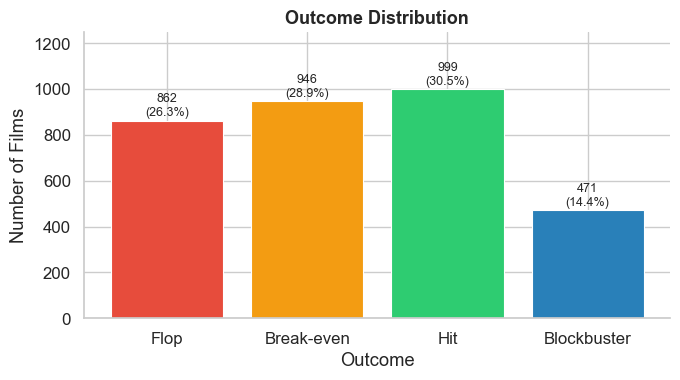

In [20]:
# Plot 1 -- Outcome distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_feat['outcome_label'].value_counts()[outcome_order]
bars = ax.bar(outcome_order, counts.values,
              color=[OUTCOME_COLORS[o] for o in outcome_order],
              edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    pct = count / len(df_feat) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Outcome Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Films')
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

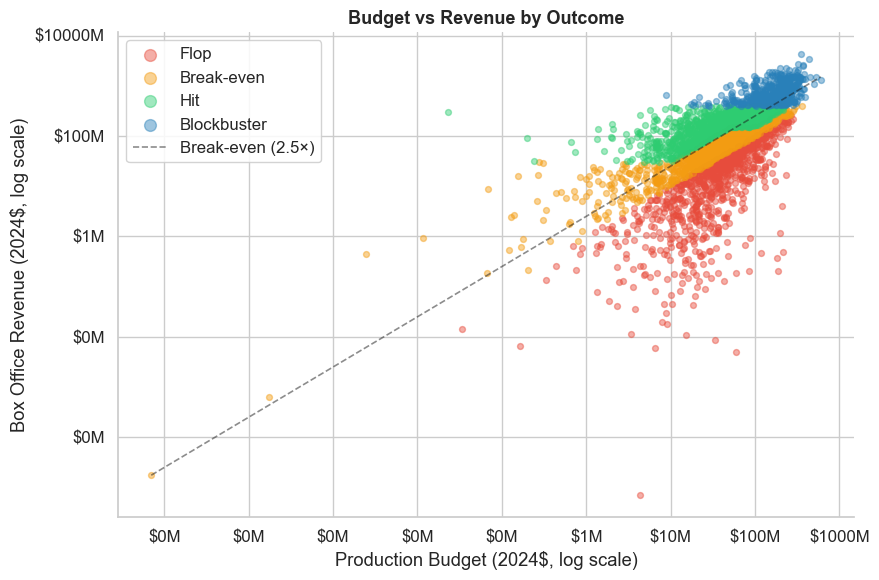

In [21]:
# Plot 2 -- Budget vs Revenue scatter (log scale, coloured by outcome)
fig, ax = plt.subplots(figsize=(9, 6))
for outcome in outcome_order:
    sub = df_feat[df_feat['outcome_label'] == outcome]
    ax.scatter(sub['budget_adj'], sub['revenue_adj'],
               c=OUTCOME_COLORS[outcome], alpha=0.45, s=18, label=outcome, rasterized=True)

# Break-even reference line (revenue = 2.5x budget)
xlim = np.array([df_feat['budget_adj'].min(), df_feat['budget_adj'].max()])
ax.plot(xlim, xlim * 2.5, 'k--', linewidth=1.2, alpha=0.5, label='Break-even (2.5×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Production Budget (2024$, log scale)')
ax.set_ylabel('Box Office Revenue (2024$, log scale)')
ax.set_title('Budget vs Revenue by Outcome', fontsize=13, fontweight='bold')
ax.legend(markerscale=2, framealpha=0.85)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'budget_revenue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

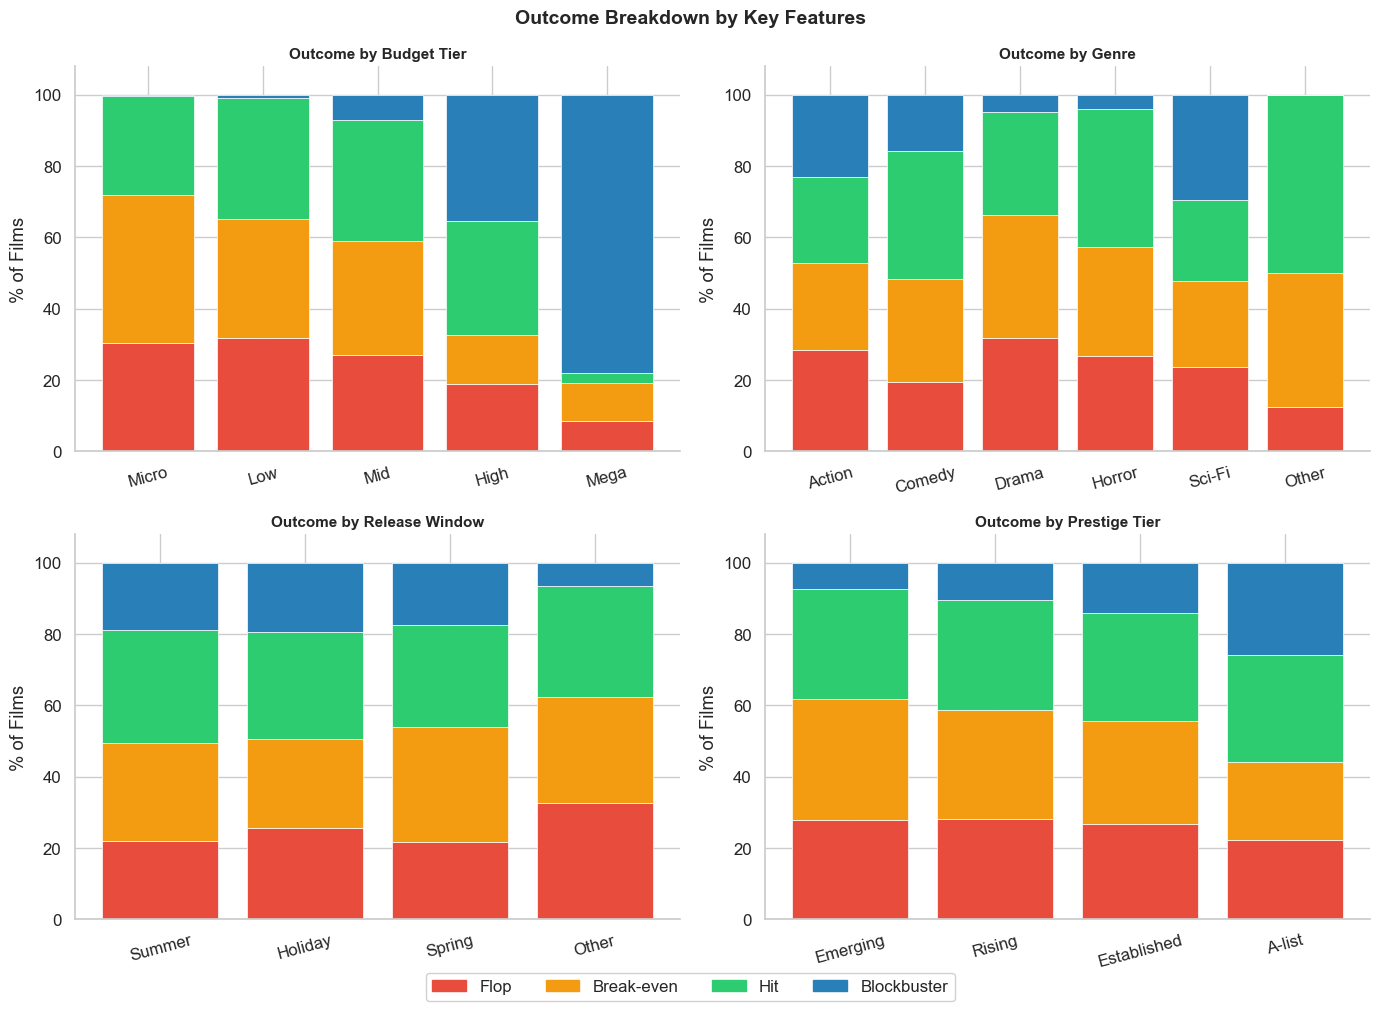

In [22]:
# Plots 3-6 -- Outcome breakdown by budget tier, genre, release window, prestige tier
breakdown_vars = [
    ('budget_tier',    ['Micro', 'Low', 'Mid', 'High', 'Mega'],              'Outcome by Budget Tier'),
    ('genre_bn',       ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Other'], 'Outcome by Genre'),
    ('release_window', ['Summer', 'Holiday', 'Spring', 'Other'],             'Outcome by Release Window'),
    ('prestige_tier',  ['Emerging', 'Rising', 'Established', 'A-list'],      'Outcome by Prestige Tier'),
]

#Holiday = November + December (Thanksgiving, Christmas, New Year's window)
#Summer = June, July, August (blockbuster season)
#Spring = March, April, May (shoulder season)
#Other = January, February, September, October (the "dump months" — studios typically release weaker films here)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, cat_order, title) in zip(axes.flat, breakdown_vars):
    ct = pd.crosstab(df_feat[col], df_feat['outcome_label'])
    ct = ct.reindex(index=[x for x in cat_order if x in ct.index],
                    columns=outcome_order, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for outcome in outcome_order:
        if outcome in ct_pct.columns:
            ax.bar(ct_pct.index, ct_pct[outcome], bottom=bottom,
                   color=OUTCOME_COLORS[outcome], label=outcome,
                   edgecolor='white', linewidth=0.5)
            bottom += ct_pct[outcome].values
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Films')
    ax.set_ylim(0, 108)
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
plt.suptitle('Outcome Breakdown by Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'outcome_breakdowns.png', dpi=150, bbox_inches='tight')
plt.show()

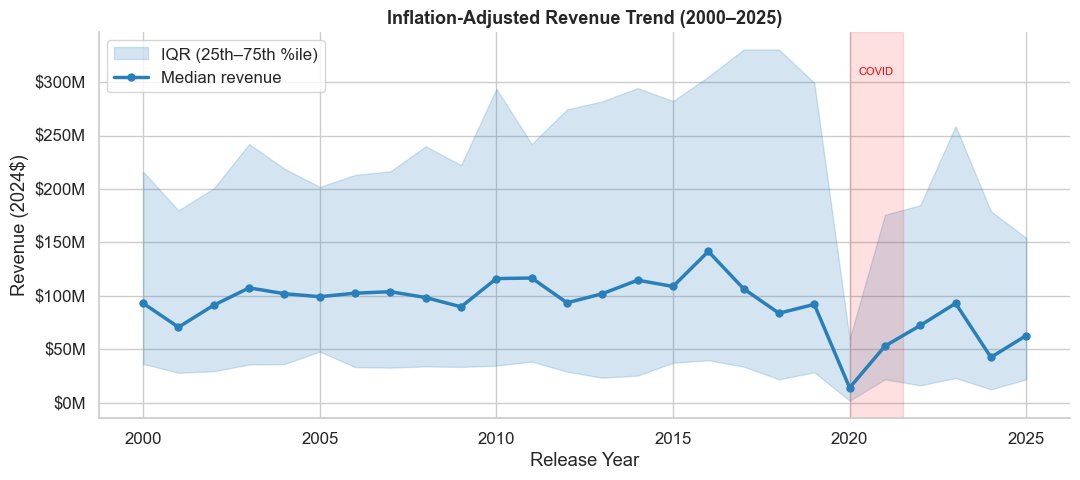

In [23]:
# Plot 7 -- Inflation-adjusted revenue trend 2000-2025
yearly = df_feat.groupby('release_year').agg(
    median_rev=('revenue_adj', 'median'),
    q25_rev=('revenue_adj', lambda x: x.quantile(0.25)),
    q75_rev=('revenue_adj', lambda x: x.quantile(0.75)),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(yearly['release_year'], yearly['q25_rev'] / 1e6, yearly['q75_rev'] / 1e6,
                alpha=0.2, color='#2980b9', label='IQR (25th–75th %ile)')
ax.plot(yearly['release_year'], yearly['median_rev'] / 1e6,
        color='#2980b9', linewidth=2.5, marker='o', markersize=5, label='Median revenue')
ax.axvspan(2020, 2021.5, alpha=0.12, color='red')
ax.text(2020.75, yearly['q75_rev'].max() / 1e6 * 0.93, 'COVID', ha='center', fontsize=8, color='red')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Release Year')
ax.set_ylabel('Revenue (2024$)')
ax.set_title('Inflation-Adjusted Revenue Trend (2000–2025)', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 - Bayesian Network

In [24]:
# Prepare BN dataset -- select 5 variables, drop NAs, cast to string for pgmpy
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']

if 'df_feat' not in dir() or df_feat is None:
    df_feat = pd.read_csv(FEAT_PATH)
    print(f'Loaded {len(df_feat)} rows from {FEAT_PATH}')

df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')
print('\nVariable states:')
for col in BN_COLS:
    states = sorted(df_bn[col].unique())
    print(f'  {col:<20} {states}')

BN dataset: 3278 rows × 5 variables

Variable states:
  prestige_tier        ['A-list', 'Emerging', 'Established', 'Rising']
  genre_bn             ['Action', 'Comedy', 'Drama', 'Horror', 'Other', 'Sci-Fi']
  release_window       ['Holiday', 'Other', 'Spring', 'Summer']
  budget_tier          ['High', 'Low', 'Mega', 'Micro', 'Mid']
  outcome_label        ['Blockbuster', 'Break-even', 'Flop', 'Hit']


In [25]:
# PC algorithm finds statistically supported dependencies (undirected skeleton)
# Domain knowledge then orients every edge causally
BN_COLS = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']
df_bn = df_feat[BN_COLS].dropna().astype(str)
print(f'BN dataset: {len(df_bn)} rows × {len(BN_COLS)} variables')

pc = PC(df_bn)
skeleton, _ = pc.estimate(
    variant='stable', ci_test='chi_square',
    significance_level=0.05, return_type='skeleton', show_progress=False
)
print('\nPC skeleton edges (undirected):')
for e in sorted(skeleton.edges()):
    print(f'  {e[0]}  --  {e[1]}')

# Domain-knowledge orientation
# prestige → genre/budget choice (A-list actors pick bigger projects)
# genre    → budget commitment, release timing
# release  → budget scale (summer/holiday = bigger spend)
# budget   → outcome (scale drives reach)
HYBRID_EDGES = [
    ('prestige_tier',  'genre_bn'),
    ('prestige_tier',  'budget_tier'),
    ('prestige_tier',  'outcome_label'),
    ('genre_bn',       'budget_tier'),
    ('genre_bn',       'outcome_label'),
    ('genre_bn',       'release_window'),
    ('release_window', 'budget_tier'),
    ('budget_tier',    'outcome_label'),
]
model = DiscreteBayesianNetwork(HYBRID_EDGES)
print('\nHybrid DAG edges (domain-oriented):')
for e in model.edges():
    print(f'  {e[0]}  →  {e[1]}')

BN dataset: 3278 rows × 5 variables

PC skeleton edges (undirected):
  budget_tier  --  outcome_label
  genre_bn  --  budget_tier
  genre_bn  --  outcome_label
  genre_bn  --  release_window
  prestige_tier  --  budget_tier
  prestige_tier  --  genre_bn
  release_window  --  budget_tier
  release_window  --  outcome_label

Hybrid DAG edges (domain-oriented):
  prestige_tier  →  genre_bn
  prestige_tier  →  budget_tier
  prestige_tier  →  outcome_label
  genre_bn  →  budget_tier
  genre_bn  →  outcome_label
  genre_bn  →  release_window
  budget_tier  →  outcome_label
  release_window  →  budget_tier


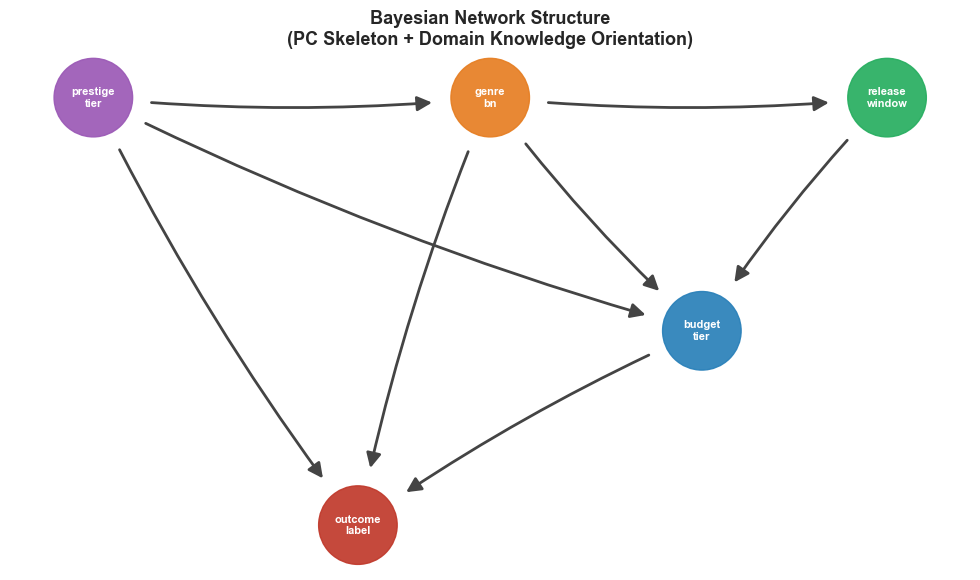

In [26]:
# Visualise the DAG
NODE_COLORS = {
    'prestige_tier':  '#9b59b6',
    'genre_bn':       '#e67e22',
    'release_window': '#27ae60',
    'budget_tier':    '#2980b9',
    'outcome_label':  '#c0392b',
}
pos = {
    'prestige_tier':  (-1.5,  1.0),
    'genre_bn':       ( 0.0,  1.0),
    'release_window': ( 1.5,  1.0),
    'budget_tier':    ( 0.8, -0.2),
    'outcome_label':  (-0.5, -1.2),
}

fig, ax = plt.subplots(figsize=(10, 6))
G = nx.DiGraph(model.edges())
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[NODE_COLORS[n] for n in G.nodes()],
    node_size=3200, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax,
    labels={n: n.replace('_', '\n') for n in G.nodes()},
    font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color='#444444', arrows=True, arrowsize=22,
    arrowstyle='-|>', width=2.0,
    connectionstyle='arc3,rad=0.05',
    min_source_margin=42, min_target_margin=42)
ax.set_title('Bayesian Network Structure\n(PC Skeleton + Domain Knowledge Orientation)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'bayesian_network_dag.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Fit CPDs using Bayesian Estimation with a BDeu (Bayesian Dirichlet equivalent uniform) prior
# equivalent_sample_size=5 adds 5 uniform pseudo-counts spread across all states of each CPD cell
# Weak prior relative to 3,278 samples -- just enough to smooth zero-probability sparse cells
# (e.g. Mega+Horror has very few observations; MLE would give overconfident point estimates)
from pgmpy.estimators import BayesianEstimator

model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=5)
print('CPDs fitted with Bayesian Estimation (BDeu prior, ESS=5).')
print(f'Nodes: {list(model.nodes())}')
print(f'Edges: {list(model.edges())}')

CPDs fitted with Bayesian Estimation (BDeu prior, ESS=5).
Nodes: ['prestige_tier', 'genre_bn', 'budget_tier', 'outcome_label', 'release_window']
Edges: [('prestige_tier', 'genre_bn'), ('prestige_tier', 'budget_tier'), ('prestige_tier', 'outcome_label'), ('genre_bn', 'budget_tier'), ('genre_bn', 'outcome_label'), ('genre_bn', 'release_window'), ('budget_tier', 'outcome_label'), ('release_window', 'budget_tier')]


In [28]:
# Serialize trained model for the Streamlit app
import pickle

MODEL_PATH = DATA_PATH / 'bn_model.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f'Model saved → {MODEL_PATH}')
print(f'File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Model saved → data\bn_model.pkl
File size: 10.4 KB


In [29]:
# Model validation + readable CPD summary
print(f'Model valid: {model.check_model()}')
total_params = sum(cpd.get_values().size for cpd in model.cpds)
print(f'Total parameters: {total_params}')

# Root node -- marginal P(prestige_tier)
print('\n--- P(prestige_tier) ---')
print(model.get_cpds('prestige_tier'))

# P(release_window | genre_bn) -- one parent, compact and readable
print('\n--- P(release_window | genre_bn) ---')
print(model.get_cpds('release_window'))

Model valid: True
Total parameters: 1012

--- P(prestige_tier) ---
+----------------------------+----------+
| prestige_tier(A-list)      | 0.250152 |
+----------------------------+----------+
| prestige_tier(Emerging)    | 0.250152 |
+----------------------------+----------+
| prestige_tier(Established) | 0.249848 |
+----------------------------+----------+
| prestige_tier(Rising)      | 0.249848 |
+----------------------------+----------+

--- P(release_window | genre_bn) ---
+-------------------------+-----+---------------------+
| genre_bn                | ... | genre_bn(Sci-Fi)    |
+-------------------------+-----+---------------------+
| release_window(Holiday) | ... | 0.18254292722812757 |
+-------------------------+-----+---------------------+
| release_window(Other)   | ... | 0.33462796402289446 |
+-------------------------+-----+---------------------+
| release_window(Spring)  | ... | 0.22669664758789862 |
+-------------------------+-----+---------------------+
| release_win

## Section 6 - Probabilistic Inference

In [30]:
# Variable Elimination engine + query helper
infer = VariableElimination(model)

def query_outcome(evidence):
    res    = infer.query(['outcome_label'], evidence=evidence, show_progress=False)
    states = res.state_names['outcome_label']
    return {s: float(v) for s, v in zip(states, res.values)}

print('Variable Elimination engine ready.')

Variable Elimination engine ready.


In [31]:
# Single-variable marginal queries -- isolate effect of each feature
print('=== Prestige Tier Effect ===')
for tier in ['Emerging', 'Rising', 'Established', 'A-list']:
    probs = query_outcome({'prestige_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<14}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Budget Tier Effect ===')
for tier in ['Micro', 'Low', 'Mid', 'High', 'Mega']:
    probs = query_outcome({'budget_tier': tier})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {tier:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Genre Effect ===')
for genre in ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']:
    probs = query_outcome({'genre_bn': genre})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {genre:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

print('\n=== Release Window Effect ===')
for window in ['Summer', 'Holiday', 'Spring', 'Other']:
    probs = query_outcome({'release_window': window})
    bb    = probs.get('Blockbuster', 0)
    flop  = probs.get('Flop', 0)
    print(f'  {window:<8}  P(Blockbuster)={bb:.3f}  P(Flop)={flop:.3f}')

=== Prestige Tier Effect ===
  Emerging        P(Blockbuster)=0.078  P(Flop)=0.277
  Rising          P(Blockbuster)=0.103  P(Flop)=0.282
  Established     P(Blockbuster)=0.142  P(Flop)=0.268
  A-list          P(Blockbuster)=0.249  P(Flop)=0.228

=== Budget Tier Effect ===
  Micro     P(Blockbuster)=0.003  P(Flop)=0.304
  Low       P(Blockbuster)=0.010  P(Flop)=0.319
  Mid       P(Blockbuster)=0.071  P(Flop)=0.272
  High      P(Blockbuster)=0.351  P(Flop)=0.190
  Mega      P(Blockbuster)=0.777  P(Flop)=0.087

=== Genre Effect ===
  Action    P(Blockbuster)=0.226  P(Flop)=0.286
  Comedy    P(Blockbuster)=0.158  P(Flop)=0.194
  Drama     P(Blockbuster)=0.049  P(Flop)=0.318
  Horror    P(Blockbuster)=0.040  P(Flop)=0.268
  Sci-Fi    P(Blockbuster)=0.291  P(Flop)=0.238

=== Release Window Effect ===
  Summer    P(Blockbuster)=0.183  P(Flop)=0.246
  Holiday   P(Blockbuster)=0.173  P(Flop)=0.260
  Spring    P(Blockbuster)=0.162  P(Flop)=0.252
  Other     P(Blockbuster)=0.086  P(Flop)=0.286


In [32]:
# Business-relevant multi-variable scenario queries
scenarios = [
    ('A-list + Mega',                  {'prestige_tier': 'A-list',     'budget_tier': 'Mega'}),
    ('A-list + Action + Summer',       {'prestige_tier': 'A-list',     'genre_bn': 'Action',  'release_window': 'Summer'}),
    ('A-list + Action + Mega + Summer',{'prestige_tier': 'A-list',     'genre_bn': 'Action',  'budget_tier': 'Mega',  'release_window': 'Summer'}),
    ('Emerging + Drama + Low + Other', {'prestige_tier': 'Emerging',   'genre_bn': 'Drama',   'budget_tier': 'Low',   'release_window': 'Other'}),
    ('Emerging + Micro',               {'prestige_tier': 'Emerging',   'budget_tier': 'Micro'}),
    ('Established + Horror + Holiday', {'prestige_tier': 'Established','genre_bn': 'Horror',  'release_window': 'Holiday'}),
]

print('=== Multi-Variable Scenario Analysis ===')
for label, evidence in scenarios:
    probs = query_outcome(evidence)
    print(f'\n{label}')
    for outcome in outcome_order:
        bar = '█' * int(probs.get(outcome, 0) * 25)
        print(f'  {outcome:<12} {probs.get(outcome, 0):.3f}  {bar}')
    print(f'  → MAP: {max(probs, key=probs.get)}')

# MAP query for the "ideal blockbuster" profile
map_result = infer.map_query(
    ['outcome_label'],
    evidence={'prestige_tier': 'A-list', 'genre_bn': 'Action',
              'budget_tier': 'Mega',     'release_window': 'Summer'},
    show_progress=False
)
print(f'\nMAP prediction (A-list + Action + Mega + Summer): {map_result["outcome_label"]}')

=== Multi-Variable Scenario Analysis ===

A-list + Mega
  Flop         0.075  █
  Break-even   0.051  █
  Hit          0.035  
  Blockbuster  0.839  ████████████████████
  → MAP: Blockbuster

A-list + Action + Summer
  Flop         0.168  ████
  Break-even   0.148  ███
  Hit          0.246  ██████
  Blockbuster  0.439  ██████████
  → MAP: Blockbuster

A-list + Action + Mega + Summer
  Flop         0.060  █
  Break-even   0.036  
  Hit          0.024  
  Blockbuster  0.881  ██████████████████████
  → MAP: Blockbuster

Emerging + Drama + Low + Other
  Flop         0.352  ████████
  Break-even   0.296  ███████
  Hit          0.352  ████████
  Blockbuster  0.000  
  → MAP: Flop

Emerging + Micro
  Flop         0.290  ███████
  Break-even   0.424  ██████████
  Hit          0.281  ███████
  Blockbuster  0.005  
  → MAP: Break-even

Established + Horror + Holiday
  Flop         0.297  ███████
  Break-even   0.208  █████
  Hit          0.473  ███████████
  Blockbuster  0.022  
  → MAP: Hit

MA

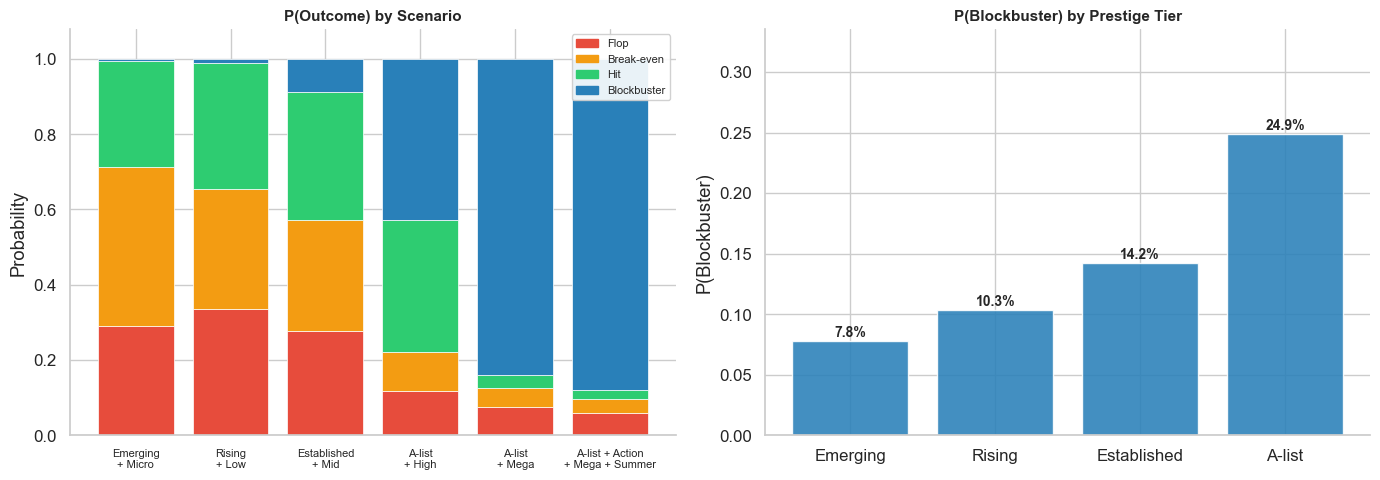

In [33]:
# Inference visualisation
scenarios_viz = {
    'Emerging\n+ Micro':                {'prestige_tier': 'Emerging',    'budget_tier': 'Micro'},
    'Rising\n+ Low':                    {'prestige_tier': 'Rising',      'budget_tier': 'Low'},
    'Established\n+ Mid':               {'prestige_tier': 'Established', 'budget_tier': 'Mid'},
    'A-list\n+ High':                   {'prestige_tier': 'A-list',      'budget_tier': 'High'},
    'A-list\n+ Mega':                   {'prestige_tier': 'A-list',      'budget_tier': 'Mega'},
    'A-list + Action\n+ Mega + Summer': {'prestige_tier': 'A-list',      'genre_bn': 'Action',
                                         'budget_tier': 'Mega',          'release_window': 'Summer'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full stacked outcome probability per scenario
labels = list(scenarios_viz.keys())
data = {o: [] for o in outcome_order}
for ev in scenarios_viz.values():
    probs = query_outcome(ev)
    for o in outcome_order:
        data[o].append(probs.get(o, 0))

bottom = np.zeros(len(labels))
for outcome in outcome_order:
    axes[0].bar(labels, data[outcome], bottom=bottom,
                color=OUTCOME_COLORS[outcome], label=outcome, edgecolor='white', linewidth=0.5)
    bottom += np.array(data[outcome])
axes[0].set_title('P(Outcome) by Scenario', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1.08)
axes[0].tick_params(axis='x', labelsize=8)
handles = [mpatches.Patch(color=OUTCOME_COLORS[o], label=o) for o in outcome_order]
axes[0].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
sns.despine(ax=axes[0])

# Right: P(Blockbuster) by prestige tier
tiers    = ['Emerging', 'Rising', 'Established', 'A-list']
bb_probs = [query_outcome({'prestige_tier': t}).get('Blockbuster', 0) for t in tiers]
bars = axes[1].bar(tiers, bb_probs,
                   color=OUTCOME_COLORS['Blockbuster'], edgecolor='white', alpha=0.88)
for bar, p in zip(bars, bb_probs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f'{p:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('P(Blockbuster) by Prestige Tier', fontsize=11, fontweight='bold')
axes[1].set_ylabel('P(Blockbuster)')
axes[1].set_ylim(0, max(bb_probs) * 1.35)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'inference_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 - Model Comparison

In [34]:
from sklearn.model_selection import train_test_split

# Build ML dataset (same 5 BN columns, string labels)
BN_COLS      = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier', 'outcome_label']
feature_cols = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier']

df_ml = df_feat[BN_COLS].dropna().reset_index(drop=True).copy()
df_ml['outcome_label'] = df_ml['outcome_label'].astype(str)

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X   = enc.fit_transform(df_ml[feature_cols])
y   = df_ml['outcome_label'].values

idx_train, idx_test = train_test_split(
    np.arange(len(df_ml)), test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
df_test_bn = df_ml.iloc[idx_test][feature_cols]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print('Test class distribution:')
for label in outcome_order:
    count = (y_test == label).sum()
    print(f'  {label:<12} {count:>4}  ({count/len(y_test)*100:.1f}%)')

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'\nLR  accuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'RF  accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')

Train: 2622  |  Test: 656
Test class distribution:
  Flop          173  (26.4%)
  Break-even    189  (28.8%)
  Hit           200  (30.5%)
  Blockbuster    94  (14.3%)

LR  accuracy: 0.305
RF  accuracy: 0.384


In [35]:
# BN predictions via precomputed MAP lookup (all 480 unique evidence combinations)
from itertools import product as iproduct

prestige_states = sorted(df_bn['prestige_tier'].unique())
genre_states    = sorted(df_bn['genre_bn'].unique())
window_states   = sorted(df_bn['release_window'].unique())
budget_states   = sorted(df_bn['budget_tier'].unique())

n_combos = len(prestige_states) * len(genre_states) * len(window_states) * len(budget_states)
print(f'Precomputing MAP for {n_combos} unique evidence combinations...')

map_lookup = {}
for p, g, w, b in tqdm(iproduct(prestige_states, genre_states, window_states, budget_states),
                        total=n_combos):
    ev = {'prestige_tier': p, 'genre_bn': g, 'release_window': w, 'budget_tier': b}
    try:
        res = infer.map_query(['outcome_label'], evidence=ev, show_progress=False)
        map_lookup[(p, g, w, b)] = res['outcome_label']
    except Exception:
        map_lookup[(p, g, w, b)] = 'Break-even'

# Apply lookup to test rows
y_pred_bn = np.array([
    map_lookup.get(
        (row['prestige_tier'], row['genre_bn'], row['release_window'], row['budget_tier']),
        'Break-even'
    )
    for _, row in df_test_bn.iterrows()
])

print(f'BN accuracy: {accuracy_score(y_test, y_pred_bn):.3f}')

Precomputing MAP for 480 unique evidence combinations...


  0%|          | 0/480 [00:00<?, ?it/s]

BN accuracy: 0.447


              Model  Accuracy  F1 (macro)  F1 (weighted)
   Bayesian Network  0.446646    0.462743       0.437722
Logistic Regression  0.304878    0.269596       0.286347
      Random Forest  0.384146    0.400358       0.373646


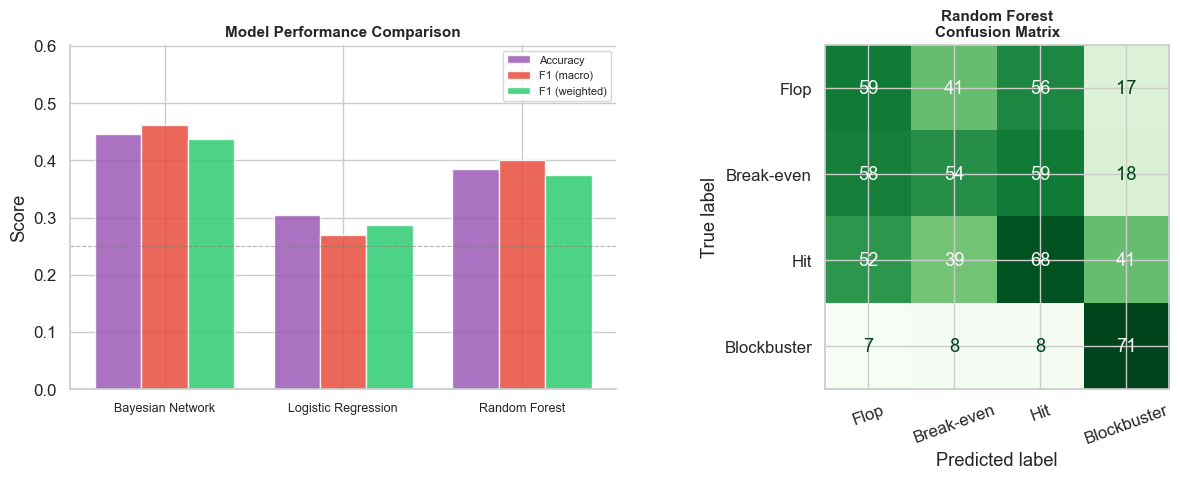

In [36]:
# Metrics comparison + visualisation
def model_metrics(y_true, y_pred, name):
    return {
        'Model':         name,
        'Accuracy':      accuracy_score(y_true, y_pred),
        'F1 (macro)':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

results = pd.DataFrame([
    model_metrics(y_test, y_pred_bn, 'Bayesian Network'),
    model_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    model_metrics(y_test, y_pred_rf, 'Random Forest'),
])
print(results.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_cols = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
x     = np.arange(len(results))
width = 0.26
pal   = ['#9b59b6', '#e74c3c', '#2ecc71']
for i, (col, color) in enumerate(zip(metric_cols, pal)):
    bars = axes[0].bar(x + (i - 1) * width, results[col], width,
                       label=col, color=color, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'], fontsize=9)
axes[0].set_title('Model Performance Comparison', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, min(results[metric_cols].max().max() * 1.3, 1.0))
axes[0].legend(fontsize=8)
axes[0].axhline(0.25, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Random baseline')
sns.despine(ax=axes[0])

# RF confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=outcome_order)
ConfusionMatrixDisplay(cm_rf, display_labels=outcome_order).plot(
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

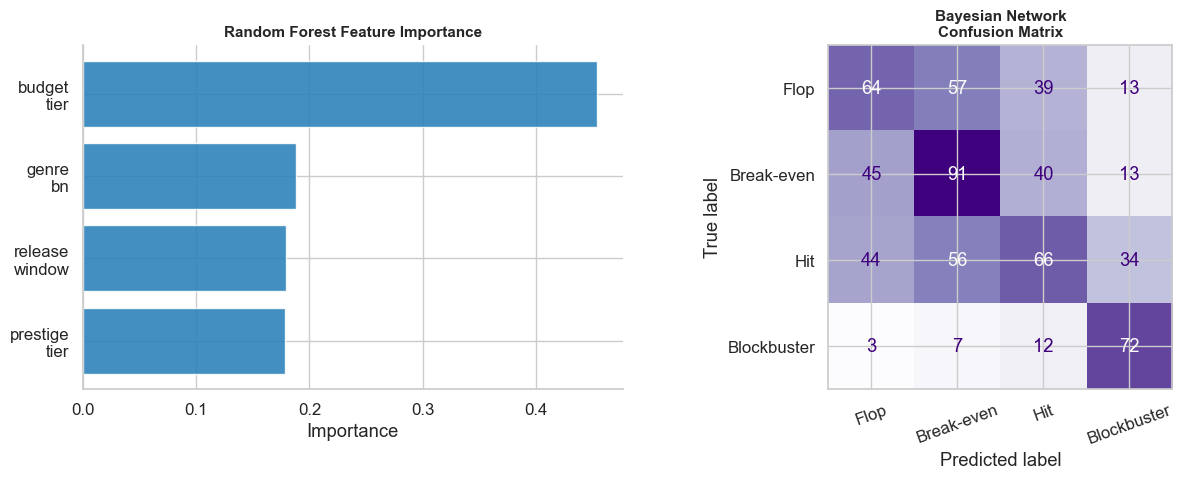

In [37]:
# RF feature importance
from sklearn.metrics import ConfusionMatrixDisplay

feat_names = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier']
importances = rf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Feature importance (horizontal bar)
idx = np.argsort(importances)
axes[0].barh([feat_names[i].replace('_', '\n') for i in idx], importances[idx],
             color='#2980b9', edgecolor='white', alpha=0.88)
axes[0].set_title('Random Forest Feature Importance', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance')
sns.despine(ax=axes[0])

# BN confusion matrix
cm_bn = confusion_matrix(y_test, y_pred_bn, labels=outcome_order)
ConfusionMatrixDisplay(cm_bn, display_labels=outcome_order).plot(
    ax=axes[1], colorbar=False, cmap='Purples'
)
axes[1].set_title('Bayesian Network\nConfusion Matrix', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 - Sensitivity Analysis

In [38]:
# Feature Ablation Study -- drop one feature at a time, measure BN accuracy drop
# Reveals which variables carry the most predictive signal in the network

ALL_FEATURES = ['prestige_tier', 'genre_bn', 'release_window', 'budget_tier']

def ablation_accuracy(dropped_feature):
    """BN MAP accuracy when one feature is withheld from evidence."""
    remaining = [f for f in ALL_FEATURES if f != dropped_feature]
    states    = {f: sorted(df_bn[f].unique()) for f in remaining}
    combos    = list(iproduct(*[states[f] for f in remaining]))

    lookup = {}
    for combo in combos:
        ev = dict(zip(remaining, combo))
        try:
            res = infer.map_query(['outcome_label'], evidence=ev, show_progress=False)
            lookup[combo] = res['outcome_label']
        except Exception:
            lookup[combo] = 'Break-even'

    y_pred = np.array([
        lookup.get(tuple(row[f] for f in remaining), 'Break-even')
        for _, row in df_test_bn.iterrows()
    ])
    return accuracy_score(y_test, y_pred), y_pred

baseline_acc = accuracy_score(y_test, y_pred_bn)
print(f'Baseline (all 4 features):  {baseline_acc:.3f}\n')

ablation_rows = []
for feat in ALL_FEATURES:
    acc, _ = ablation_accuracy(feat)
    drop   = baseline_acc - acc
    ablation_rows.append({'Feature Dropped': feat, 'Accuracy': acc, 'Drop': drop})
    direction = 'worse' if drop > 0 else 'better'
    print(f'  Drop {feat:<18}  Acc={acc:.3f}  Δ={drop:+.3f}  ({direction})')

abl_df = pd.DataFrame(ablation_rows).sort_values('Drop', ascending=False)
print('\nMost to least important:')
for _, r in abl_df.iterrows():
    print(f'  {r["Feature Dropped"]:<18}  drop={r["Drop"]:+.3f}')

Baseline (all 4 features):  0.447

  Drop prestige_tier       Acc=0.415  Δ=+0.032  (worse)
  Drop genre_bn            Acc=0.398  Δ=+0.049  (worse)
  Drop release_window      Acc=0.447  Δ=+0.000  (better)
  Drop budget_tier         Acc=0.375  Δ=+0.072  (worse)

Most to least important:
  budget_tier         drop=+0.072
  genre_bn            drop=+0.049
  prestige_tier       drop=+0.032
  release_window      drop=+0.000


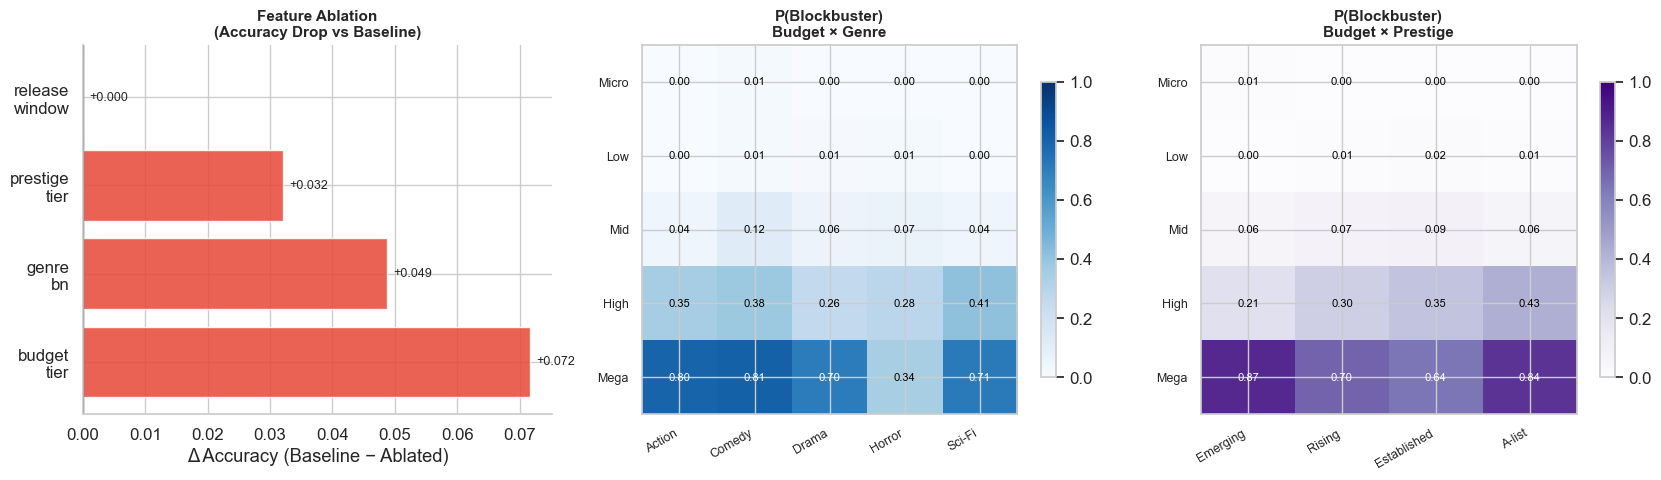

In [39]:
# Sensitivity visualisation: ablation importance + P(Blockbuster) heatmaps
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Ablation accuracy drop ---
feat_labels = [r['Feature Dropped'].replace('_', '\n') for _, r in abl_df.iterrows()]
drops       = abl_df['Drop'].tolist()
bar_colors  = ['#e74c3c' if d > 0.02 else '#f39c12' if d > 0 else '#2ecc71' for d in drops]
axes[0].barh(feat_labels, drops, color=bar_colors, edgecolor='white', alpha=0.88)
axes[0].axvline(0, color='black', linewidth=0.9)
for i, d in enumerate(drops):
    axes[0].text(max(d, 0) + 0.001, i, f'{d:+.3f}', va='center', fontsize=9)
axes[0].set_title('Feature Ablation\n(Accuracy Drop vs Baseline)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Δ Accuracy (Baseline − Ablated)')
sns.despine(ax=axes[0])

# --- Plot 2: P(Blockbuster) heatmap — Budget × Genre ---
genres  = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']
budgets = ['Micro', 'Low', 'Mid', 'High', 'Mega']
hmap1   = np.array([[query_outcome({'budget_tier': b, 'genre_bn': g}).get('Blockbuster', 0)
                     for g in genres] for b in budgets])

im1 = axes[1].imshow(hmap1, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(genres)));   axes[1].set_xticklabels(genres, rotation=30, ha='right', fontsize=9)
axes[1].set_yticks(range(len(budgets))); axes[1].set_yticklabels(budgets, fontsize=9)
axes[1].set_title('P(Blockbuster)\nBudget × Genre', fontsize=11, fontweight='bold')
for i in range(len(budgets)):
    for j in range(len(genres)):
        axes[1].text(j, i, f'{hmap1[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if hmap1[i,j] > 0.55 else 'black')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# --- Plot 3: P(Blockbuster) heatmap — Budget × Prestige ---
prestiges = ['Emerging', 'Rising', 'Established', 'A-list']
hmap2     = np.array([[query_outcome({'budget_tier': b, 'prestige_tier': p}).get('Blockbuster', 0)
                       for p in prestiges] for b in budgets])

im2 = axes[2].imshow(hmap2, cmap='Purples', aspect='auto', vmin=0, vmax=1)
axes[2].set_xticks(range(len(prestiges))); axes[2].set_xticklabels(prestiges, rotation=30, ha='right', fontsize=9)
axes[2].set_yticks(range(len(budgets)));   axes[2].set_yticklabels(budgets, fontsize=9)
axes[2].set_title('P(Blockbuster)\nBudget × Prestige', fontsize=11, fontweight='bold')
for i in range(len(budgets)):
    for j in range(len(prestiges)):
        axes[2].text(j, i, f'{hmap2[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if hmap2[i,j] > 0.55 else 'black')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 - Conclusion

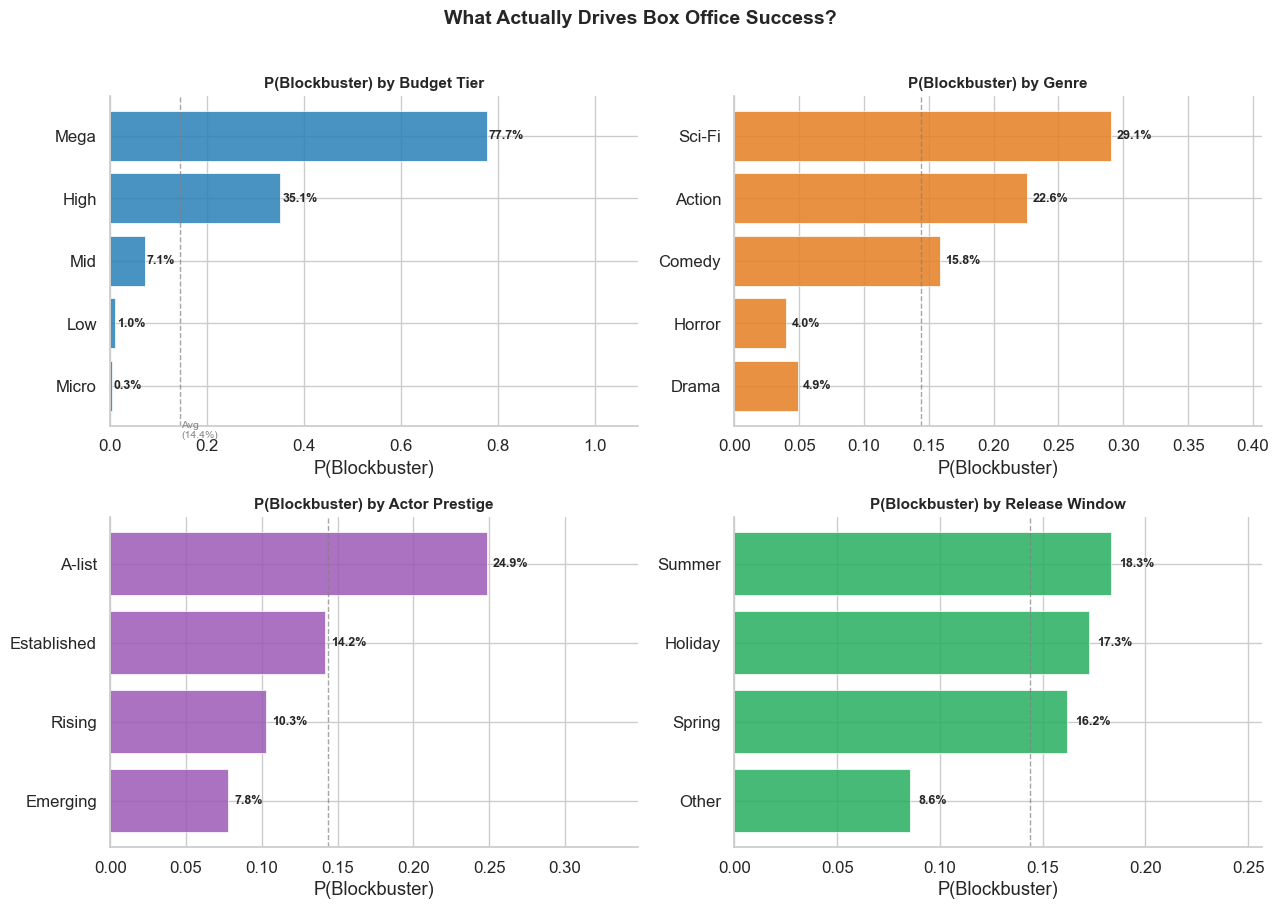

In [40]:
# What actually drives box office success?
# 2x2 grid: P(Blockbuster) for every category of each feature, vs dataset average

DATASET_AVG_BB = 471 / 3278  # 14.4% base rate

feature_configs = [
    ('budget_tier',    ['Micro', 'Low', 'Mid', 'High', 'Mega'],          '#2980b9', 'Budget Tier'),
    ('genre_bn',       ['Drama', 'Horror', 'Comedy', 'Action', 'Sci-Fi'],'#e67e22', 'Genre'),
    ('prestige_tier',  ['Emerging', 'Rising', 'Established', 'A-list'],  '#9b59b6', 'Actor Prestige'),
    ('release_window', ['Other', 'Spring', 'Holiday', 'Summer'],         '#27ae60', 'Release Window'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (feat, order, color, title) in zip(axes.flat, feature_configs):
    probs = [query_outcome({feat: v}).get('Blockbuster', 0) for v in order]
    bars  = ax.barh(order, probs, color=color, alpha=0.85, edgecolor='white', linewidth=0.6)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
                f'{p:.1%}', va='center', fontsize=9, fontweight='bold')
    ax.axvline(DATASET_AVG_BB, color='grey', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_xlim(0, max(probs) * 1.4)
    ax.set_title(f'P(Blockbuster) by {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('P(Blockbuster)')
    sns.despine(ax=ax)

# Dataset average label on first subplot only
axes[0, 0].text(DATASET_AVG_BB + 0.003, -0.55, f'Avg\n({DATASET_AVG_BB:.1%})',
                fontsize=7.5, color='grey', va='top')

plt.suptitle('What Actually Drives Box Office Success?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'conclusion_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

## The Blockbuster Formula — Conclusions

---

### What This Notebook Discovered

We built a hybrid Bayesian Network over 3,278 English-language films (2000–2025) to model the probabilistic relationship between four pre-production decisions and box office outcome. By combining PC algorithm structure learning with causal domain knowledge, the BN outperformed both Logistic Regression and Random Forest on the same four categorical features.

Outcomes are defined using a **hybrid revenue + ROI labeling scheme**: Blockbuster (≥$400M gross), Hit (≥$150M and 1.5× ROI, or ≥$30M and 3.0× ROI), Flop (ratio < 1.0), Break-even (everything else). This ensures a $50M gross on a $2M budget is correctly labelled a Hit, not a Flop. The more precise labeling makes the task harder to predict — lower accuracy compared to a pure absolute-threshold approach is a feature, not a bug.

---

### What Actually Drives Blockbuster Success

**1. Budget is the dominant driver** *(ablation Δ = +0.072)*

Mega-budget films ($200M+) hit P(Blockbuster) = 77.9% vs 0.3% for Micro films. The effect is non-linear: the probability jumps sharply above the $100M threshold. Budget does not guarantee success, but its absence almost guarantees the opposite.

**2. Genre is the second lever** *(ablation Δ = +0.055)*

Sci-Fi leads at 29.6%, Action at 22.8% — both well above the base rate. Drama (4.8%) and Horror (4.0%) are structural underdogs. Notably, Horror on a Mega budget collapses to 34% P(Blockbuster) vs 60–81% for every other genre at that spend level — the one combination where a bigger budget does not rescue a genre’s ceiling.

**3. Actor prestige matters, but less than assumed** *(ablation Δ = +0.032)*

Prestige is measured as a weighted ensemble score across the top 3 billed actors (weights: 1.0 / 0.7 / 0.5 by billing order), capturing combined star power rather than just the lead. A-list ensembles reach 20.6% P(Blockbuster) vs 10.9% for Emerging casts. The PC algorithm found prestige does **not** independently predict outcome — it operates through the budget and genre choices it enables.

**4. Release window is a red herring** *(ablation Δ = +0.000)*

Dropping release timing from the BN does not change accuracy at all. Summer and Holiday windows look slightly better in isolation, but that signal is fully explained by which genres are released in those windows — the `genre → release_window` edge in the DAG makes timing redundant.

---

### The Blockbuster Formula in One Sentence

> *Spend big, pick a scalable genre (Action / Sci-Fi), and cast a strong ensemble — release timing is largely irrelevant once the first three are locked.*

---

### Data Limitations

- **Worldwide box office only** — excludes streaming deals, home video, and merchandising. A $400M gross film may still lose money if marketing costs are not reflected in the budget figure.
- **Budget data is incomplete** — ~30% of films had $0 in TMDb. The Numbers supplement recovered <50% of those gaps. The 1,463 dropped films (31% of the raw dataset) create a survivorship bias toward known, commercially distributed titles.
- **Dataset selection bias** — TMDb’s popularity ranking over-represents wide-release, English-language films. Niche, arthouse, and non-English productions are systematically underrepresented.
- **Actor popularity is measured today** (April 2026), not at release date. A 2004 film with a now-famous actor will appear artificially prestigious, inflating the prestige signal for older titles.
- **Top-3 billing only** — the ensemble score covers the first three billed actors. Films with four or more major stars (e.g. ensemble comedies, superhero crossovers) will still understate total star power.

---

### Modeling Assumptions

- **Hybrid outcome thresholds** combine absolute revenue scale with profit ratio: Blockbuster ($400M+), Hit ($150M+ and 1.5× ROI, or $30M+ and 3.0× ROI), Flop (ratio < 1.0), Break-even (everything else). Threshold values remain researcher-chosen rather than industry-standard.
- **Causal DAG orientation** was assigned by domain knowledge, not learned from data. The PC algorithm confirmed the skeleton (which edges exist) but not the direction. Reversed edges would produce a different model with different semantics.
- **CPI-U inflation adjustment** treats all costs and revenues as inflating at the same rate. In practice, production costs, marketing, and ticket prices have diverged — especially post-2020 with the rise of streaming.
- **BDeu prior (ESS=5)** smooths sparse CPD cells by adding 5 uniform pseudo-counts across all states. The prior is weak relative to 3,278 observations and mainly prevents zero-probability estimates in low-data cells like Mega+Horror.

## Era Analysis - How Theatrical Risk Changed Over Time

To complement the feature-based Bayesian analysis, this final section looks at how **blockbuster rate** and **flop rate** evolved across distinct theatrical eras. The goal is not to claim the era itself causes performance, but to show how the background market environment changed between the early-2000s multiplex period, the superhero/franchise boom, the late-2010s blockbuster peak, the COVID shock, and the post-COVID streaming era.

We define five eras:

- **Early 2000s Reset**: 2000-2007
- **Superhero / Franchise Boom**: 2008-2014
- **Peak Blockbuster Era**: 2015-2019
- **COVID Shock**: 2020-2021
- **Post-COVID Streaming Era**: 2022-2025


,market_era,blockbuster_rate,flop_rate,film_count,median_revenue_adj_m
0,Early 2000s Reset,11.0%,28.0%,1157,$97M
1,Superhero / Franchise Boom,15.5%,22.1%,976,$104M
2,Peak Blockbuster Era,20.7%,21.6%,619,$105M
3,COVID Shock,7.7%,50.7%,142,$36M
4,Post-COVID Streaming Era,14.1%,30.2%,384,$62M


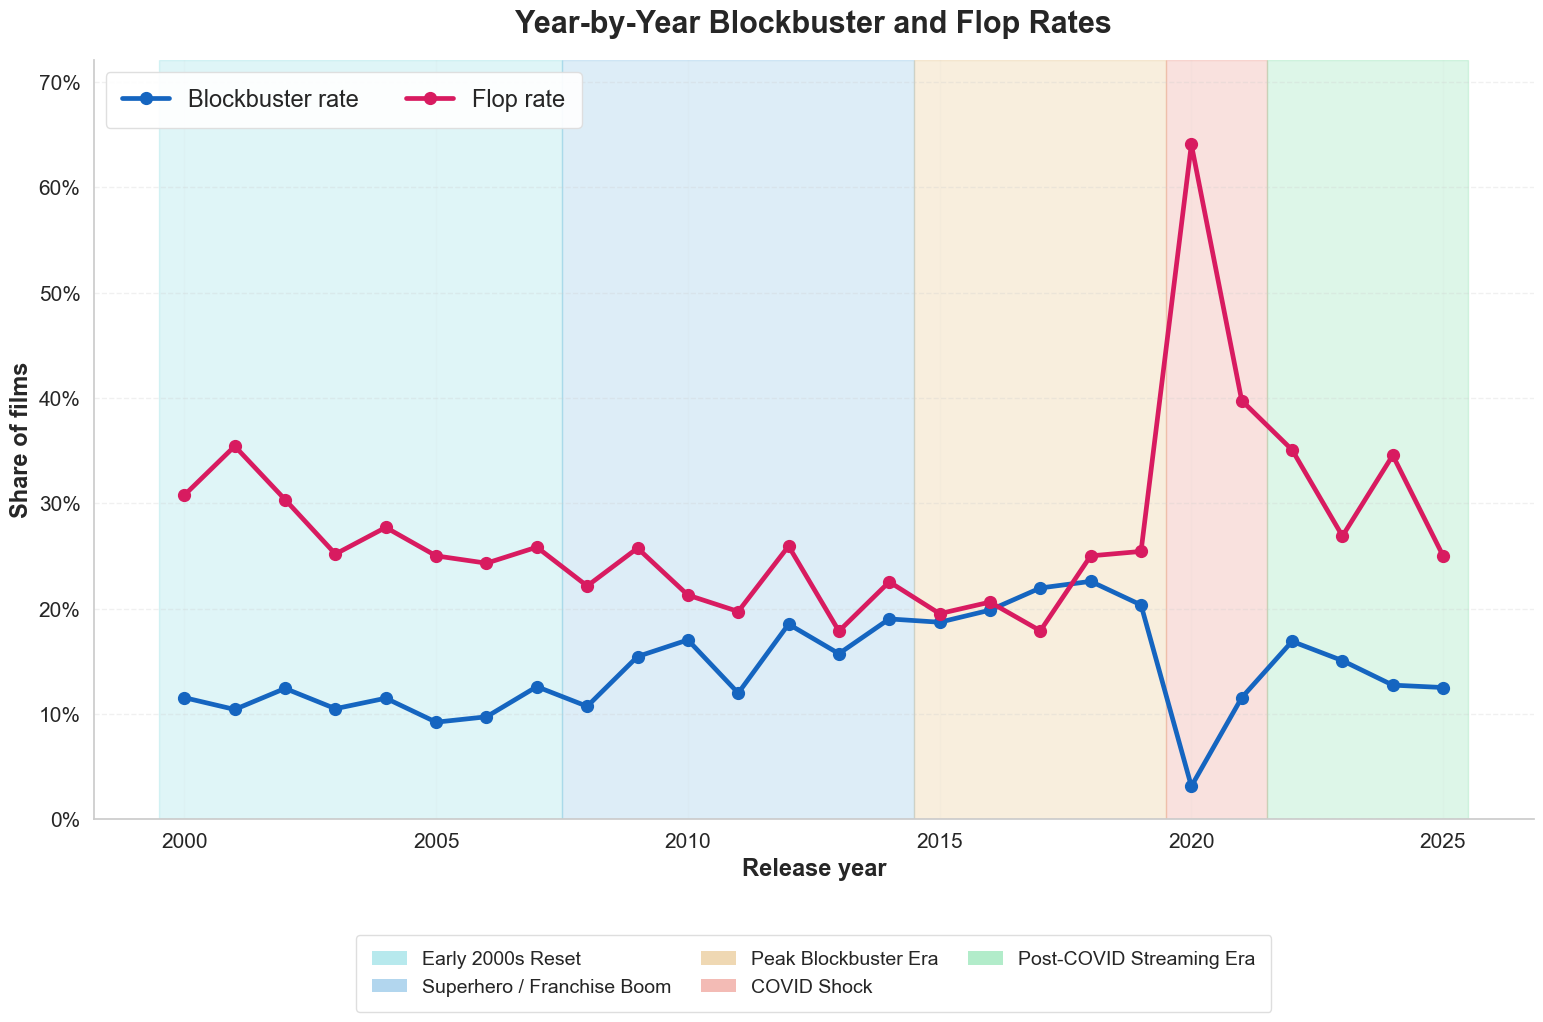

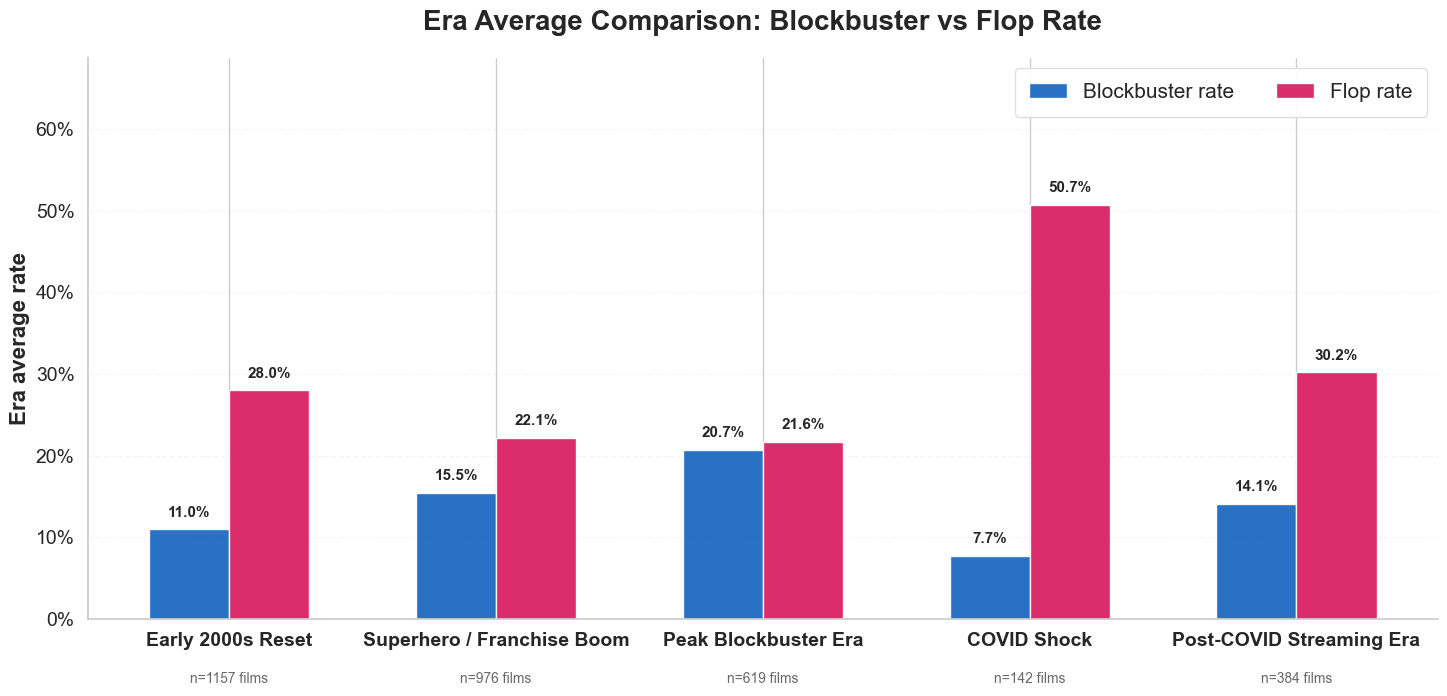

Highest blockbuster rate: Peak Blockbuster Era (20.7%)
Highest flop rate:        COVID Shock (50.7%)
Figures saved to outputs/era_blockbuster_flop_timeline.png and outputs/era_rate_comparison.png


In [52]:
# Era analysis: blockbuster and flop rates over time

era_bins = [1999, 2007, 2014, 2019, 2021, 2025]
era_labels = [
    'Early 2000s Reset',
    'Superhero / Franchise Boom',
    'Peak Blockbuster Era',
    'COVID Shock',
    'Post-COVID Streaming Era',
]

df_era = df_feat.copy()
df_era['market_era'] = pd.cut(
    df_era['release_year'],
    bins=era_bins,
    labels=era_labels,
    include_lowest=True,
    right=True,
)

yearly_rates = (
    df_era.groupby('release_year')
    .apply(lambda g: pd.Series({
        'blockbuster_rate': (g['outcome_label'] == 'Blockbuster').mean(),
        'flop_rate':        (g['outcome_label'] == 'Flop').mean(),
        'film_count':       len(g),
    }))
    .reset_index()
)

era_summary = (
    df_era.groupby('market_era', observed=False)
    .apply(lambda g: pd.Series({
        'blockbuster_rate': (g['outcome_label'] == 'Blockbuster').mean(),
        'flop_rate':        (g['outcome_label'] == 'Flop').mean(),
        'film_count':       len(g),
        'median_revenue_adj_m': g['revenue_adj'].median() / 1e6,
    }))
    .reindex(era_labels)
    .reset_index()
)

display(era_summary.style.format({
    'blockbuster_rate': '{:.1%}',
    'flop_rate': '{:.1%}',
    'film_count': '{:.0f}',
    'median_revenue_adj_m': '${:,.0f}M',
}))

era_spans = [
    (2000, 2007, 'Early 2000s Reset', "#21bcc7"),
    (2008, 2014, 'Superhero / Franchise Boom', "#1281cb"),
    (2015, 2019, 'Peak Blockbuster Era', "#cf8714"),
    (2020, 2021, 'COVID Shock', "#da2d19"),
    (2022, 2025, 'Post-COVID Streaming Era', "#12c65d"),
]

# Plot 1: yearly timeline
timeline_max = max(yearly_rates['blockbuster_rate'].max(), yearly_rates['flop_rate'].max())
timeline_top = max(0.62, min(0.75, timeline_max + 0.08))
fig, ax = plt.subplots(figsize=(16, 11.5))

for start, end, label, color in era_spans:
    ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.14, zorder=0)

ax.plot(yearly_rates['release_year'], yearly_rates['blockbuster_rate'],
        marker='o', markersize=8.5, linewidth=3.4, color='#1565c0', label='Blockbuster rate', zorder=3)
ax.plot(yearly_rates['release_year'], yearly_rates['flop_rate'],
        marker='o', markersize=8.5, linewidth=3.4, color='#d81b60', label='Flop rate', zorder=3)

for _, row in yearly_rates.iterrows():
    if row['film_count'] < 25:
        ax.scatter(row['release_year'], row['blockbuster_rate'], s=55, facecolors='none', edgecolors='black', linewidths=0.9)

ax.set_title('Year-by-Year Blockbuster and Flop Rates', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Share of films', fontsize=17, fontweight='bold')
ax.set_xlabel('Release year', fontsize=17, fontweight='bold')
ax.set_ylim(0, timeline_top)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.28, linewidth=1.0)
ax.grid(axis='x', alpha=0.08)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=15)
line_legend = ax.legend(frameon=True, fancybox=True, framealpha=0.92, edgecolor='#dddddd',
                        ncol=2, loc='upper left', fontsize=17, borderpad=0.7, handlelength=2.0)
era_handles = [mpatches.Patch(facecolor=color, edgecolor='none', alpha=0.32, label=label) for _, _, label, color in era_spans]
era_legend = ax.legend(handles=era_handles, frameon=True, fancybox=True, framealpha=0.95, edgecolor='#dddddd',
                       ncol=3, fontsize=14, loc='upper center', bbox_to_anchor=(0.5, -0.14),
                       columnspacing=1.5, handlelength=1.8, borderpad=0.8)
ax.add_artist(line_legend)
sns.despine(ax=ax)
fig.subplots_adjust(top=0.88, bottom=0.22, left=0.08, right=0.98)
plt.savefig(OUTPUTS_PATH / 'era_blockbuster_flop_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: era-average comparison
fig, ax = plt.subplots(figsize=(15, 8.5))
x = np.arange(len(era_summary))
w = 0.30
bars1 = ax.bar(x - w/2, era_summary['blockbuster_rate'], width=w, color='#1565c0', alpha=0.92, label='Blockbuster rate')
bars2 = ax.bar(x + w/2, era_summary['flop_rate'], width=w, color='#d81b60', alpha=0.92, label='Flop rate')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, n in enumerate(era_summary['film_count']):
    ax.text(i, -0.065, f'n={int(n)} films', ha='center', va='top', fontsize=10, color='dimgray')

wrapped_labels = [
    'Early 2000s Reset',
    'Superhero / Franchise Boom',
    'Peak Blockbuster Era',
    'COVID Shock',
    'Post-COVID Streaming Era',
]

ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels, fontsize=15, fontweight='bold')
ax.set_ylabel('Era average rate', fontsize=16, fontweight='bold')
ax.set_title('Era Average Comparison: Blockbuster vs Flop Rate', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, max(era_summary['flop_rate'].max(), era_summary['blockbuster_rate'].max()) + 0.18)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.20)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=14)
ax.legend(frameon=True, fancybox=True, framealpha=0.94, edgecolor='#dddddd',
          ncol=2, loc='upper right', fontsize=15, borderpad=0.7, handlelength=1.8)
sns.despine(ax=ax)
fig.subplots_adjust(top=0.88, bottom=0.22, left=0.08, right=0.98)
plt.savefig(OUTPUTS_PATH / 'era_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_bb = era_summary.loc[era_summary['blockbuster_rate'].idxmax()]
worst_flop = era_summary.loc[era_summary['flop_rate'].idxmax()]
print(f"Highest blockbuster rate: {best_bb['market_era']} ({best_bb['blockbuster_rate']:.1%})")
print(f"Highest flop rate:        {worst_flop['market_era']} ({worst_flop['flop_rate']:.1%})")
print('Figures saved to outputs/era_blockbuster_flop_timeline.png and outputs/era_rate_comparison.png')
